# STAY Layout Latent FM Sampling Demo

This notebook loads the trained latent layout flow-matching run at `artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_x4_512`, picks a few random FLIR proxy layouts, samples images from those layouts, and visualizes:

- the generated image
- uniformly spaced decoded sampling snapshots
- layout renders, boxes, masks, and conditioning maps


Using device: cuda:0
Loaded checkpoint: /projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_x4_512/UNET/unet_fm_best.pt
Loaded VAE weights: /projets/Fbassignana/diffusers_try/flow_matching_trial/artifacts/checkpoints/vae/vae_runs/flir_private_proxy_alignment_v18_vae_x4_512/VAE/vae_best.pt
Sampling 3 layouts from split='val' with 10 Euler steps
  [1] dataset_idx=391 file=video-JhYLiFCieHQHaY8o7-frame-005481-KpbYyT6uXws2HhXgE.npy objects=17 image_id=video-JhYLiFCieHQHaY8o7-frame-005481-KpbYyT6uXws2HhXgE
  [2] dataset_idx=612 file=video-Qk8msXvMopoYNDdco-frame-005115-qNLFyzu5tvStqDDz5.npy objects=12 image_id=video-Qk8msXvMopoYNDdco-frame-005115-qNLFyzu5tvStqDDz5
  [3] dataset_idx=721 file=video-k5bTJAiyEgHismN7Y-frame-006069-HMdHMek9aHLcuhsxg.npy objects=32 image_id=video-k5bTJAiyEgHismN7Y-frame-006069-HMdHMek9aHLcuhsxg


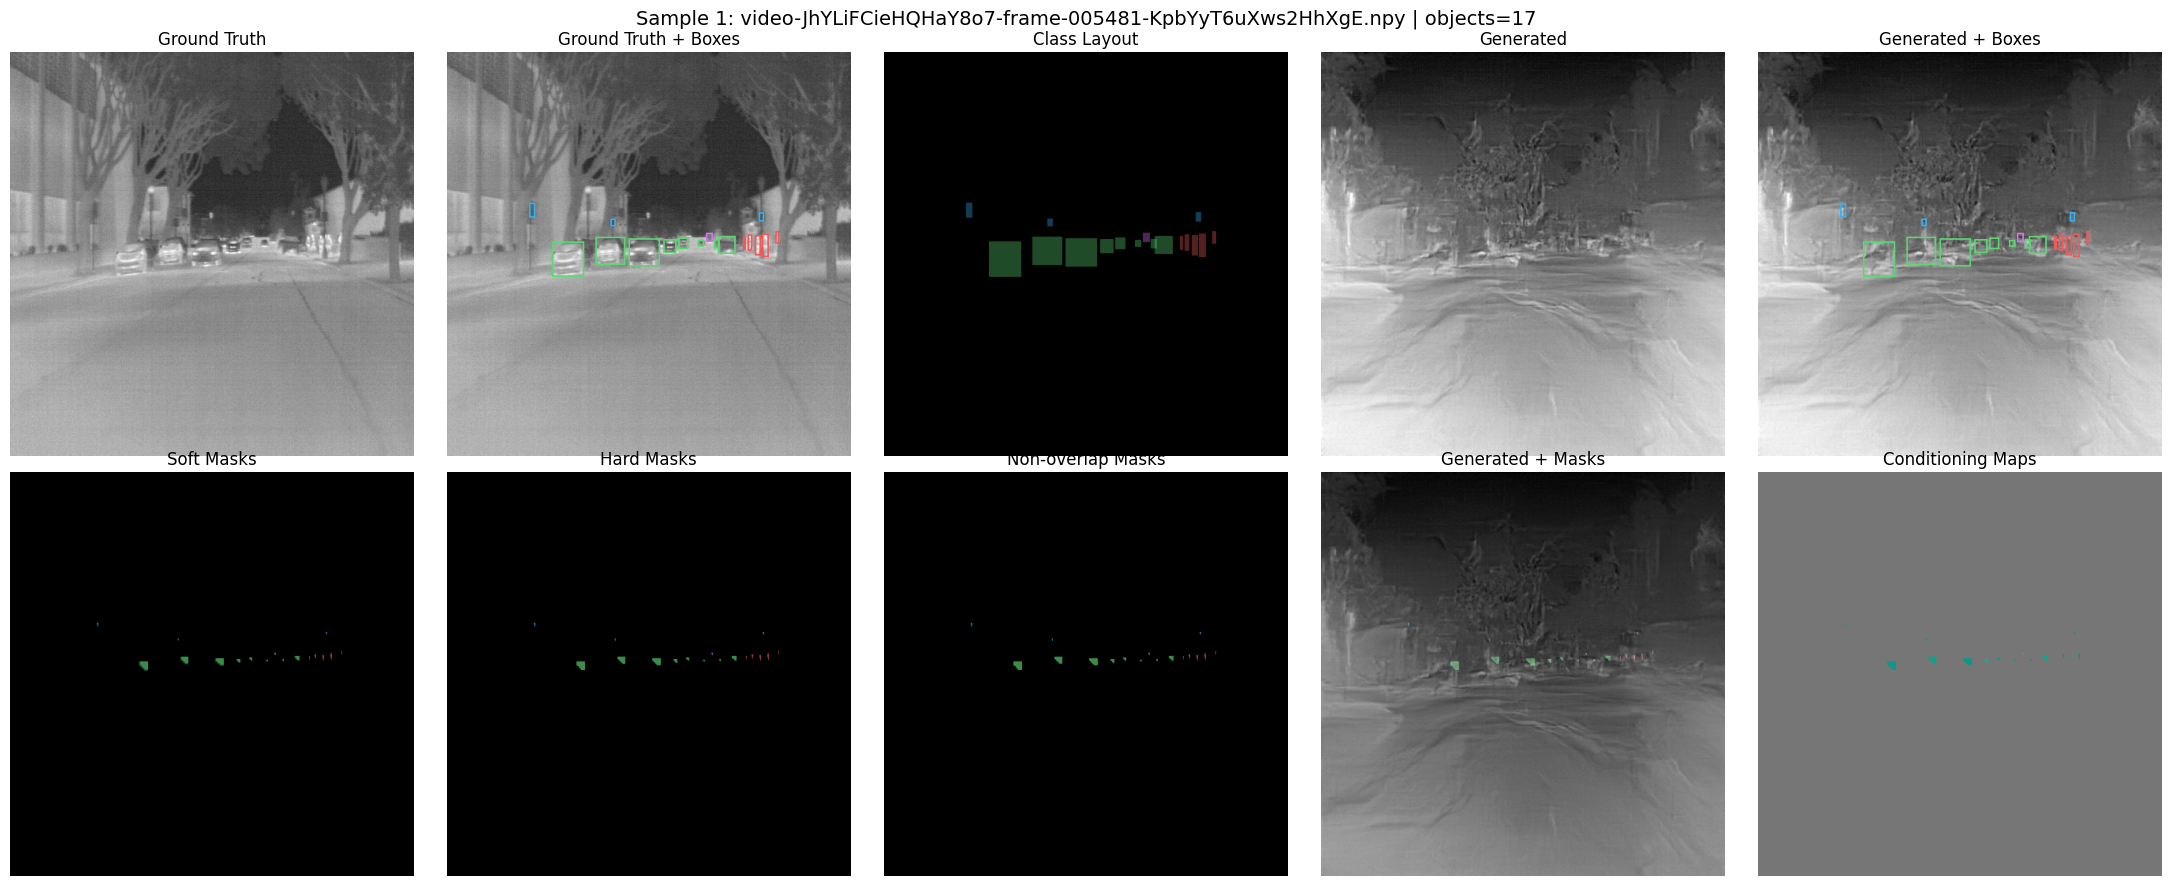

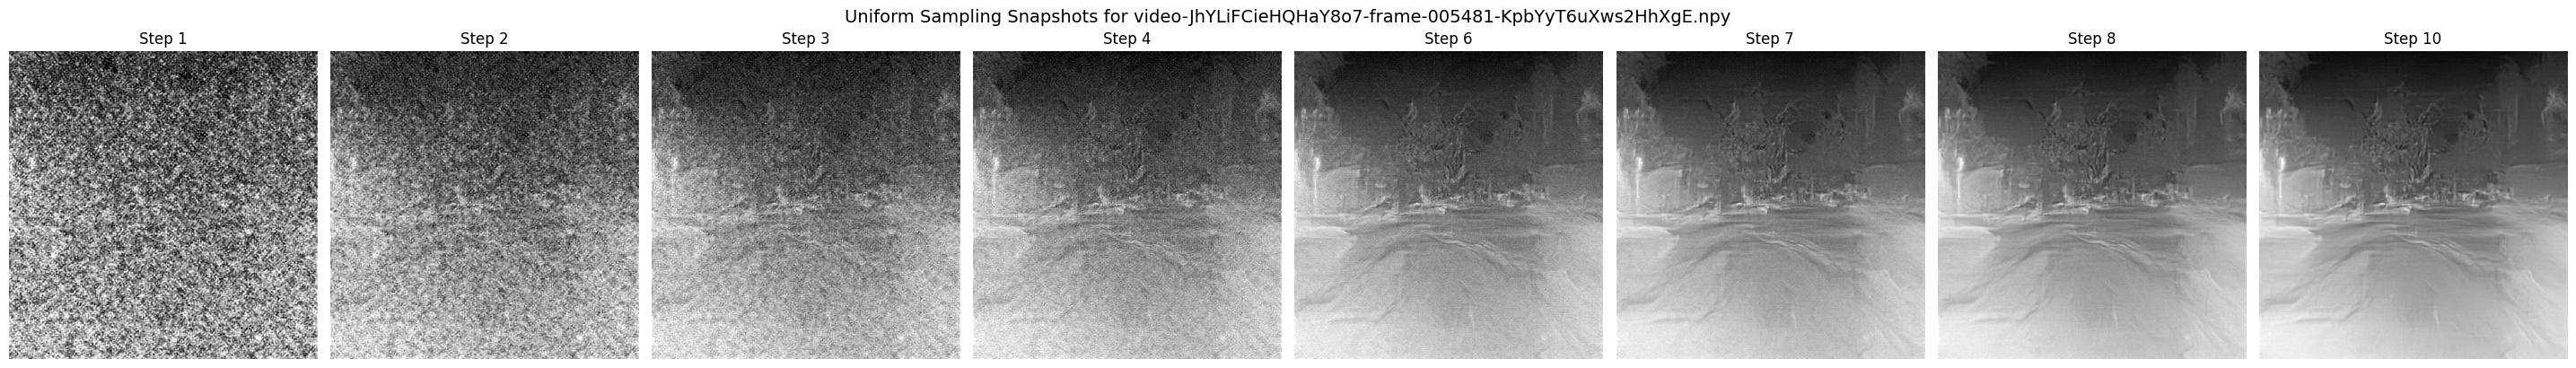

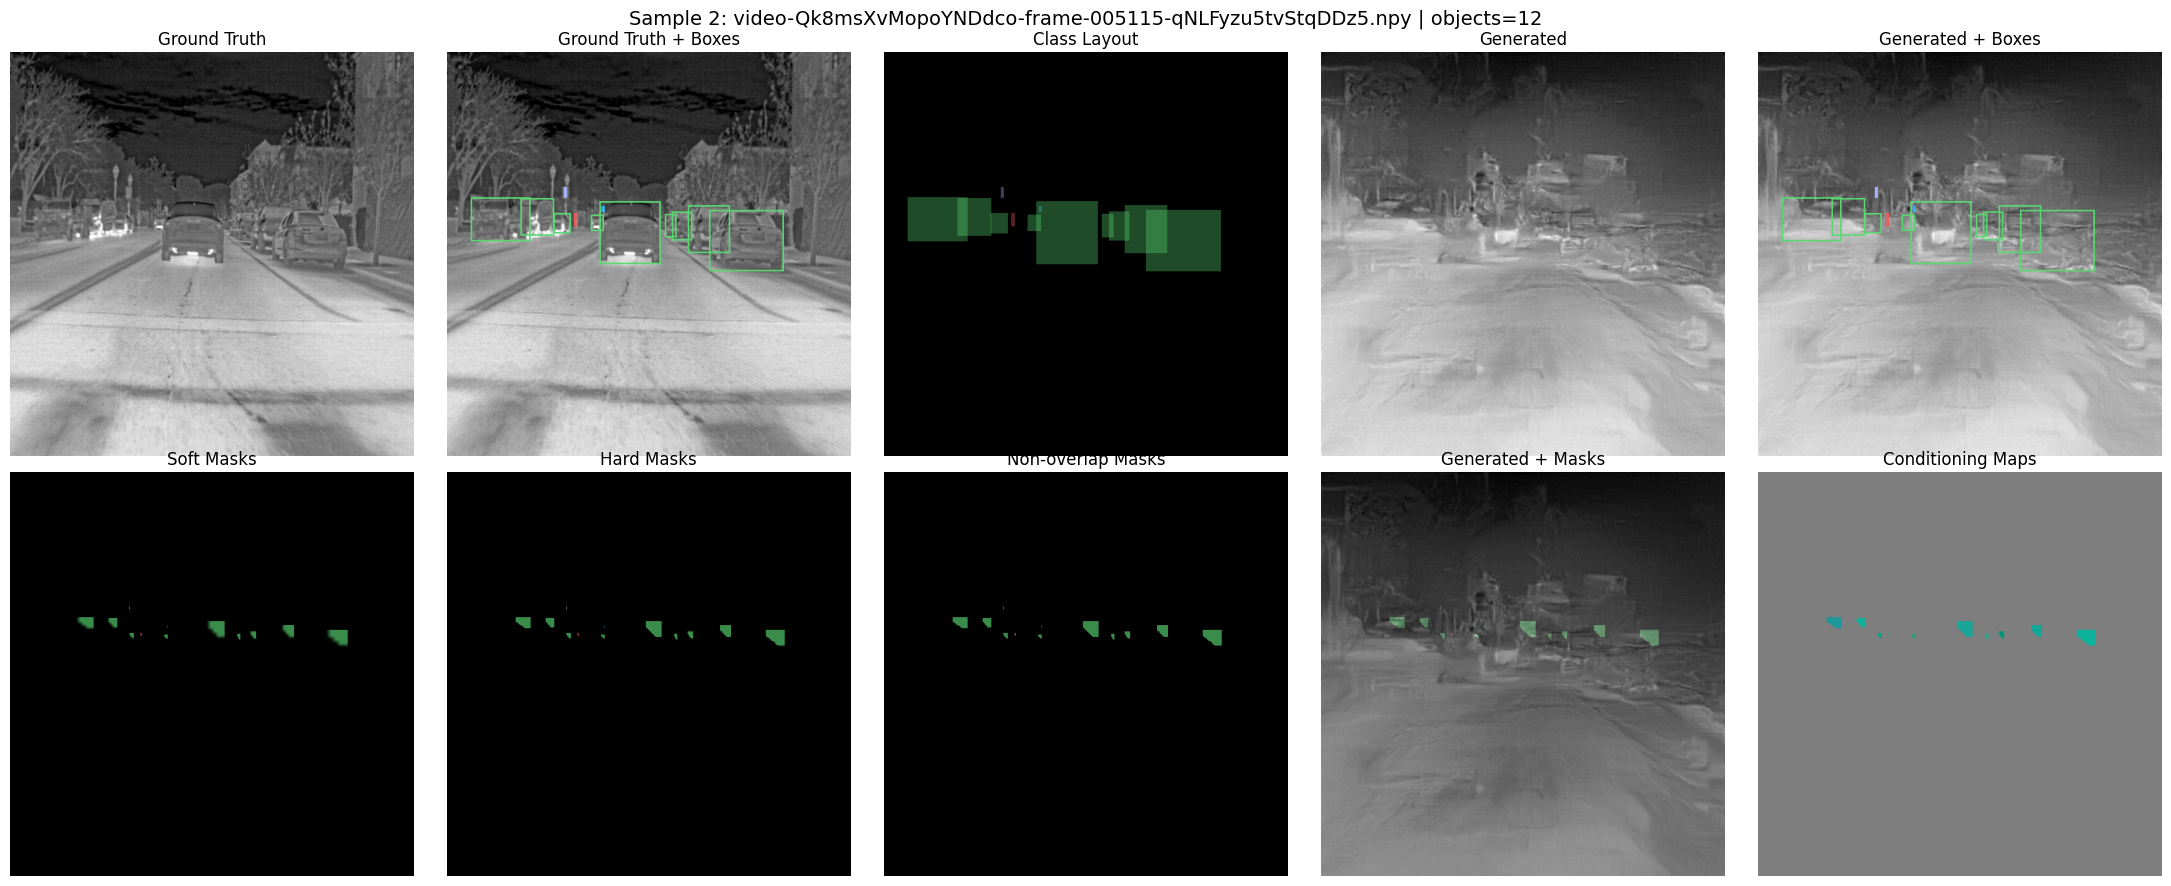

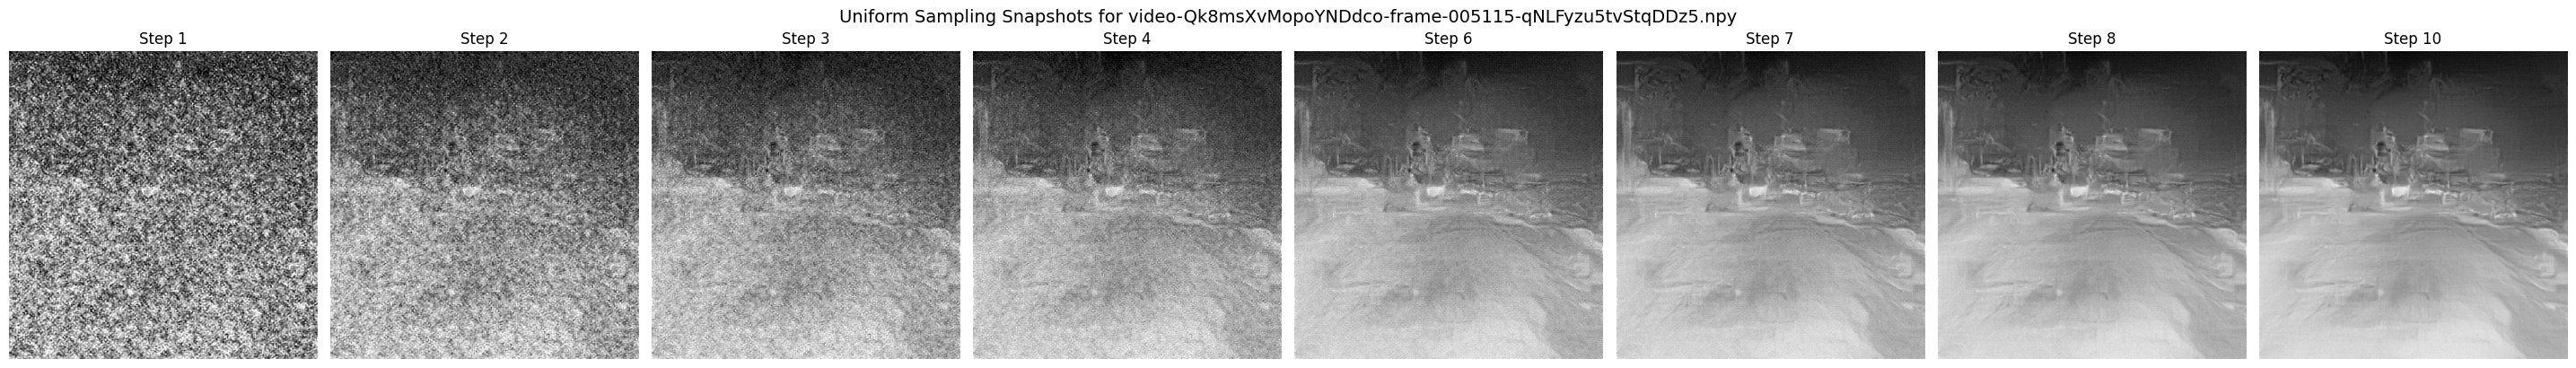

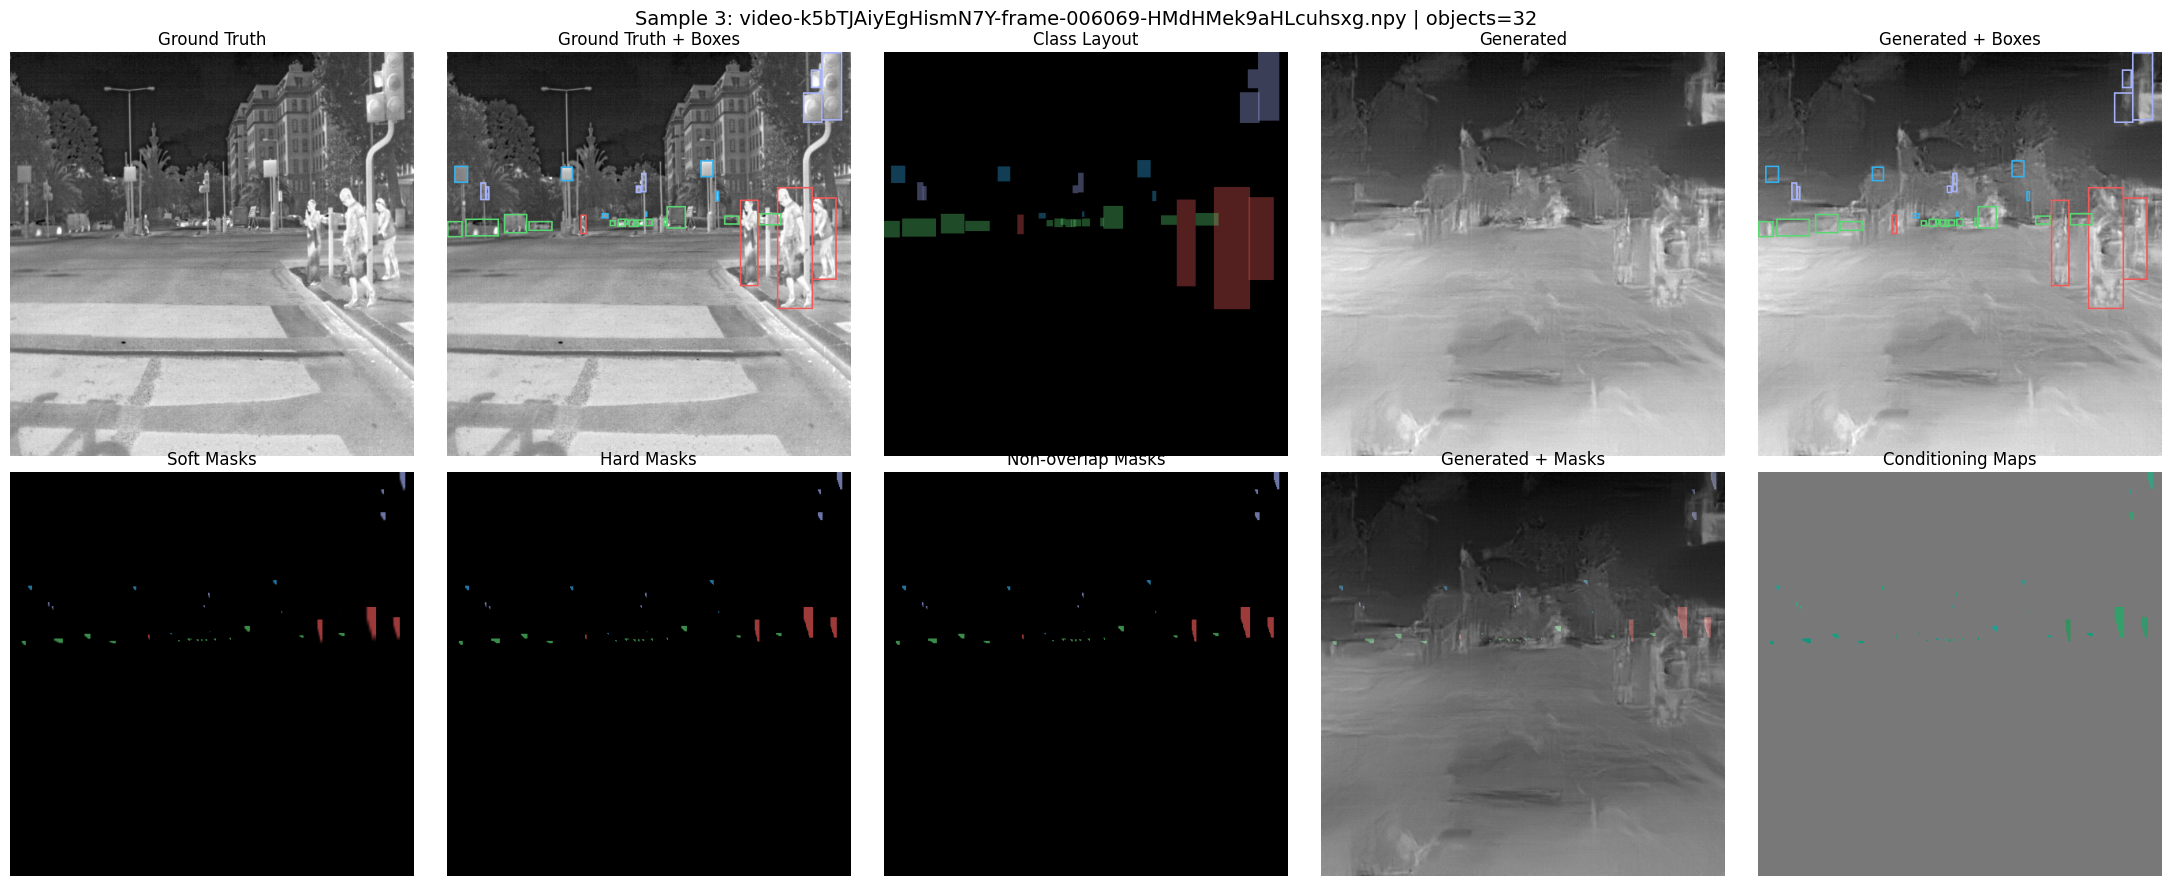

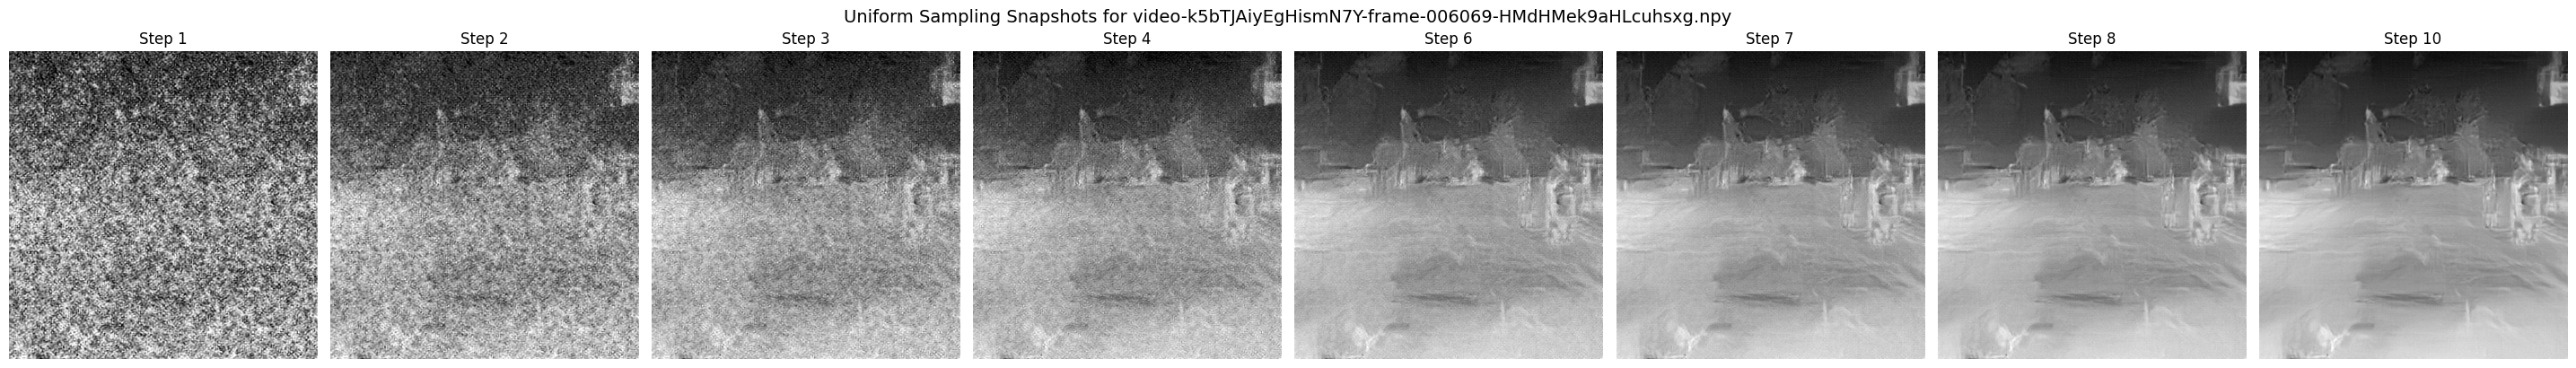

In [2]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml


def resolve_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate.resolve()
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.algorithms.inference.flow_matching_sampler import get_unet_sample_shape
from src.algorithms.inference.layout_flow_matching_sampler import LayoutFlowMatchingSampler
from src.core.data.dataset_targets import resolve_dataset_target
from src.core.data.datasets import AnnotationLayoutDataset
from src.core.data.layout_batching import collate_layout_batch
from src.core.normalization import norm_to_display as from_norm_to_display
from src.core.visualization.layout_debug import (
    draw_bbox_overlays,
    draw_mask_overlays,
    ensure_rgb,
    normalize_feature_map,
    render_class_layout,
    render_mask_composite,
)
from src.models.fm_unet import load_unet_config
from src.models.stay_layout_conditioned_unet import build_stay_layout_conditioned_unet
from src.models.vae import build_vae_from_config, freeze_vae, load_vae_config, load_vae_weights


PIPELINE_DIR = REPO_ROOT / "artifacts/checkpoints/flow_matching/serious_runs/stay_layout_latent_flir_x4_512"
PRESET_PATH = REPO_ROOT / "configs/fm/train/presets/stay_layout_latent_flir_x4_512.yaml"
CHECKPOINT_NAME = "unet_fm_best.pt"
SPLIT = "val"
NUM_LAYOUTS = 3
MIN_OBJECTS = 1
STEPS = 10
TRAJECTORY_FRAMES = 8
SEED = 7
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


def to_abs(path_like: str | Path) -> Path:
    path = Path(path_like)
    return path if path.is_absolute() else (REPO_ROOT / path).resolve()


def load_yaml(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def load_sampler_from_pipeline(
    pipeline_dir: Path,
    preset_path: Path,
    checkpoint_name: str,
    device: str,
) -> tuple[dict, dict, torch.nn.Module, torch.nn.Module, LayoutFlowMatchingSampler]:
    preset = load_yaml(preset_path)
    layout_meta = load_json(pipeline_dir / "layout_conditioning.json")
    unet_cfg = load_unet_config(str(pipeline_dir / "UNET/config.json"))
    vae_cfg = load_vae_config(str(pipeline_dir / "VAE/config.json"))

    category_id_to_name = {
        int(key): value for key, value in layout_meta.get("category_id_to_name", {}).items()
    }

    unet = build_stay_layout_conditioned_unet(
        unet_cfg,
        image_in_channels=int(layout_meta["image_in_channels"]),
        num_classes=int(layout_meta["num_classes"]),
        class_embed_dim=int(layout_meta["class_embed_dim"]),
        bbox_embed_dim=int(layout_meta["bbox_embed_dim"]),
        object_embed_dim=int(layout_meta["object_embed_dim"]),
        use_style_latent=bool(layout_meta["use_style_latent"]),
        style_latent_dim=int(layout_meta["style_latent_dim"]),
        style_seed=int(layout_meta["style_seed"]),
        mask_resolution=int(layout_meta["mask_resolution"]),
        mask_hidden_channels=int(layout_meta["mask_hidden_channels"]),
        mask_threshold=float(layout_meta["mask_threshold"]),
        edge_dilation=int(layout_meta["edge_dilation"]),
        injection_mode=str(layout_meta["injection_mode"]),
        use_masked_context=bool(layout_meta["use_masked_context"]),
        mask_overlap_loss_weight=float(layout_meta["mask_overlap_loss_weight"]),
        mask_sharpness_loss_weight=float(layout_meta["mask_sharpness_loss_weight"]),
        mask_activation_loss_weight=float(layout_meta["mask_activation_loss_weight"]),
        category_id_to_name=category_id_to_name,
        device=device,
    )

    unet_state = torch.load(pipeline_dir / "UNET" / checkpoint_name, map_location=device)
    if isinstance(unet_state, dict) and "unet_state" in unet_state:
        unet_state = unet_state["unet_state"]
    missing, unexpected = unet.load_state_dict(unet_state, strict=True)
    if missing or unexpected:
        raise RuntimeError(f"Unexpected checkpoint mismatch. missing={missing}, unexpected={unexpected}")
    unet.eval()

    vae = build_vae_from_config(vae_cfg, device=device)
    vae_weights_path = to_abs(preset["model"]["vae_weights"])
    load_vae_weights(vae, str(vae_weights_path), map_location=device)
    freeze_vae(vae)

    sampler = LayoutFlowMatchingSampler.from_stable(
        unet,
        vae,
        device=device,
        t_scale=float(preset["training"]["t_scale"]),
        train_target=str(preset["training"]["train_target"]),
        from_norm_to_display=from_norm_to_display,
    )
    return preset, layout_meta, unet, vae, sampler


def build_layout_dataset(preset: dict, split: str) -> AnnotationLayoutDataset:
    target = resolve_dataset_target(preset["data"]["dataset_id"])
    return AnnotationLayoutDataset(
        root_dir=str(target.split_dir(split)),
        annotations_path=str(target.annotations_path(split)),
        image_size=int(preset["data"]["image_size"]),
        normalization_mode=target.normalization_mode,
        include_label_names=True,
    )


def choose_random_samples(
    dataset: AnnotationLayoutDataset,
    *,
    count: int,
    seed: int,
    min_objects: int = 1,
) -> tuple[list[int], list[dict]]:
    rng = random.Random(seed)
    indices = list(range(len(dataset)))
    rng.shuffle(indices)

    chosen_indices = []
    chosen_samples = []
    for idx in indices:
        sample = dataset[idx]
        if int(sample["n_objects"]) < int(min_objects):
            continue
        chosen_indices.append(idx)
        chosen_samples.append(sample)
        if len(chosen_samples) >= count:
            break

    if not chosen_samples:
        raise RuntimeError("No layouts matched the requested filter.")
    return chosen_indices, chosen_samples


@torch.no_grad()
def sample_layout_with_trajectory(
    sampler: LayoutFlowMatchingSampler,
    batch: dict,
    *,
    steps: int,
    trajectory_frames: int,
    seed: int,
    sample_shape: tuple[int, int, int] | None = None,
) -> dict:
    sampler.unet.eval()
    batch_size = int(batch["pixel_values"].shape[0])
    shape = get_unet_sample_shape(sampler.unet, override=sample_shape or sampler._sample_shape)

    noise_generator = torch.Generator(device=sampler.device)
    noise_generator.manual_seed(seed)
    z = torch.randn(batch_size, *shape, generator=noise_generator, device=sampler.device)

    cond_kw = {
        "boxes_xyxy_norm": batch["boxes_xyxy_norm"].to(sampler.device),
        "labels": batch["labels"].to(sampler.device),
        "object_mask": batch["object_mask"].to(sampler.device),
    }
    if hasattr(sampler.unet, "sample_style_noise") and bool(getattr(sampler.unet, "use_style_latent", False)):
        style_generator = torch.Generator(device="cpu")
        style_generator.manual_seed(seed + 1000)
        cond_kw["style_noise"] = sampler.unet.sample_style_noise(
            batch_size=batch_size,
            max_objects=int(batch["labels"].shape[1]),
            device="cpu",
            dtype=batch["boxes_xyxy_norm"].dtype,
            generator=style_generator,
        ).to(sampler.device)

    dt = 1.0 / float(steps)
    snapshot_indices = sorted(
        set(np.linspace(0, steps - 1, num=min(trajectory_frames, steps), dtype=int).tolist())
    )
    decoded_frames = []

    for step_idx in range(steps):
        t_val = step_idx / float(steps)
        t = torch.full((batch_size,), t_val, device=sampler.device)
        unet_sample = sampler.unet(z, t * sampler.t_scale, **cond_kw).sample

        if sampler.train_target == "x0":
            velocity = (unet_sample - z) / (1.0 - t[:, None, None, None]).clamp(min=1e-5)
        else:
            velocity = unet_sample

        z = z + velocity * dt
        if step_idx in snapshot_indices:
            decoded_frames.append(
                {
                    "step": step_idx + 1,
                    "images": sampler.decode(z).detach().cpu(),
                }
            )

    decoded_final = sampler.decode(z).detach().cpu()
    debug = sampler.unet.build_conditioning(
        boxes_xyxy_norm=batch["boxes_xyxy_norm"].to(sampler.device),
        labels=batch["labels"].to(sampler.device),
        object_mask=batch["object_mask"].to(sampler.device),
        spatial_size=(int(batch["pixel_values"].shape[-2]), int(batch["pixel_values"].shape[-1])),
        style_noise=cond_kw.get("style_noise"),
    )
    debug = {
        key: value.detach().cpu() if torch.is_tensor(value) else value
        for key, value in debug.items()
    }
    return {
        "final_images": decoded_final,
        "frames": decoded_frames,
        "debug": debug,
    }


def prepare_visuals(batch: dict, sample_result: dict) -> dict:
    gt_display = ensure_rgb(from_norm_to_display(batch["pixel_values"]).clamp(0.0, 1.0))
    generated_display = ensure_rgb(from_norm_to_display(sample_result["final_images"]).clamp(0.0, 1.0))
    class_layout = render_class_layout(
        boxes_xyxy=batch["boxes_xyxy"],
        labels=batch["labels"],
        object_mask=batch["object_mask"],
        image_size=int(batch["pixel_values"].shape[-1]),
    )

    debug = sample_result["debug"]
    visuals = {
        "gt_display": gt_display,
        "gt_boxes": draw_bbox_overlays(
            gt_display,
            boxes_xyxy=batch["boxes_xyxy"],
            labels=batch["labels"],
            object_mask=batch["object_mask"],
        ),
        "generated_display": generated_display,
        "generated_boxes": draw_bbox_overlays(
            generated_display,
            boxes_xyxy=batch["boxes_xyxy"],
            labels=batch["labels"],
            object_mask=batch["object_mask"],
        ),
        "class_layout": class_layout,
        "conditioning_maps": normalize_feature_map(debug["conditioning_maps"]),
        "soft_masks": render_mask_composite(
            debug["soft_masks_full"],
            object_mask=batch["object_mask"],
            labels=batch["labels"],
        ),
        "hard_masks": render_mask_composite(
            debug["hard_masks_full"],
            object_mask=batch["object_mask"],
            labels=batch["labels"],
        ),
        "owner_masks": render_mask_composite(
            debug["non_overlap_masks_full"],
            object_mask=batch["object_mask"],
            labels=batch["labels"],
        ),
        "generated_mask_overlay": draw_mask_overlays(
            generated_display,
            masks=debug["hard_masks_full"],
            object_mask=batch["object_mask"],
            labels=batch["labels"],
        ),
        "trajectory": [
            {
                "step": frame["step"],
                "images": ensure_rgb(from_norm_to_display(frame["images"]).clamp(0.0, 1.0)),
            }
            for frame in sample_result["frames"]
        ],
    }
    return visuals


def show_tensor(ax, tensor: torch.Tensor, title: str) -> None:
    ax.imshow(tensor.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")


preset, layout_meta, unet, vae, sampler = load_sampler_from_pipeline(
    PIPELINE_DIR,
    PRESET_PATH,
    CHECKPOINT_NAME,
    DEVICE,
)
dataset = build_layout_dataset(preset, split=SPLIT)
chosen_indices, chosen_samples = choose_random_samples(
    dataset,
    count=NUM_LAYOUTS,
    seed=SEED,
    min_objects=MIN_OBJECTS,
)
batch = collate_layout_batch(chosen_samples)

print(f"Using device: {DEVICE}")
print(f"Loaded checkpoint: {PIPELINE_DIR / 'UNET' / CHECKPOINT_NAME}")
print(f"Loaded VAE weights: {to_abs(preset['model']['vae_weights'])}")
print(f"Sampling {len(chosen_samples)} layouts from split='{SPLIT}' with {STEPS} Euler steps")
for local_idx, (dataset_idx, sample) in enumerate(zip(chosen_indices, chosen_samples), start=1):
    print(
        f"  [{local_idx}] dataset_idx={dataset_idx} file={sample['file_name']} "
        f"objects={sample['n_objects']} image_id={sample['image_id']}"
    )

sample_result = sample_layout_with_trajectory(
    sampler,
    batch,
    steps=STEPS,
    trajectory_frames=TRAJECTORY_FRAMES,
    seed=SEED,
)
visuals = prepare_visuals(batch, sample_result)

panel_specs = [
    ("gt_display", "Ground Truth"),
    ("gt_boxes", "Ground Truth + Boxes"),
    ("class_layout", "Class Layout"),
    ("generated_display", "Generated"),
    ("generated_boxes", "Generated + Boxes"),
    ("soft_masks", "Soft Masks"),
    ("hard_masks", "Hard Masks"),
    ("owner_masks", "Non-overlap Masks"),
    ("generated_mask_overlay", "Generated + Masks"),
    ("conditioning_maps", "Conditioning Maps"),
]

for batch_idx in range(batch["pixel_values"].shape[0]):
    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()
    for axis, (tensor_key, title) in zip(axes, panel_specs):
        show_tensor(axis, visuals[tensor_key][batch_idx], title)
    fig.suptitle(
        f"Sample {batch_idx + 1}: {batch['file_name'][batch_idx]} | objects={int(batch['n_objects'][batch_idx])}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    trajectory = visuals["trajectory"]
    fig, axes = plt.subplots(1, len(trajectory), figsize=(3.6 * len(trajectory), 4.2))
    axes = np.atleast_1d(axes)
    for axis, frame in zip(axes, trajectory):
        show_tensor(axis, frame["images"][batch_idx], f"Step {frame['step']}")
    fig.suptitle(f"Uniform Sampling Snapshots for {batch['file_name'][batch_idx]}", fontsize=14)
    plt.tight_layout()
    plt.show()
